# Customer Shopping Behavior — Exploratory Data Analysis (EDA)

**Objective:** To perform a comprehensive analysis of each column in the dataset, verify its cleanliness, identify patterns, and prepare it for export to SQL.

**Stages:**
1. Data Loading and General Check
2. EDA for Each Column (Cleanliness + Distribution)
3. Logical Consistency Checks
4. Data Cleanup
5. Feature Engineering
6. Export to SQL

## 0 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Charts settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})

## 1 — Data Upload & General Inspection

In [2]:
# Import data
df = pd.read_csv('D:\Data Analysis Project\Customer Shopping Behavior Analysis\customer_shopping_behavior.csv')

print(f'Dimensions: {df.shape[0]:,} Row x {df.shape[1]} Columns')

Dimensions: 3,900 Row x 18 Columns


#### 1.1 — Quick look at the data

In [3]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


#### 1.2 — Data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

#### 1.3 — Comprehensive statistical summary 

In [5]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


#### 1.4 — Missing and Duplicate Values

In [6]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Number': missing, 'Rate %': missing_pct})
print(missing_df[missing_df['Number'] > 0])

print(f'\n=== Repeated Rows ===')
print(f'Number of duplicate rows: {df.duplicated().sum()}')

=== Missing Values ===
               Number  Rate %
Review Rating      37    0.95

=== Repeated Rows ===
Number of duplicate rows: 0


## 2 — EDA for Each Column

> For each column: (1) Hygiene check, (2) Statistics, (3) Graph.

#### 2.1 — `Customer ID` 

In [7]:
col = 'Customer ID'

print(f'Unique Values : {df[col].nunique():,}')
print(f'Sequential 1 → N : {(df[col].values == range(1, len(df)+1)).all()}')

Unique Values : 3,900
Sequential 1 → N : True


#### 2.2 — `Age` 

Range : 18 – 70
Outliers (IQR): 0



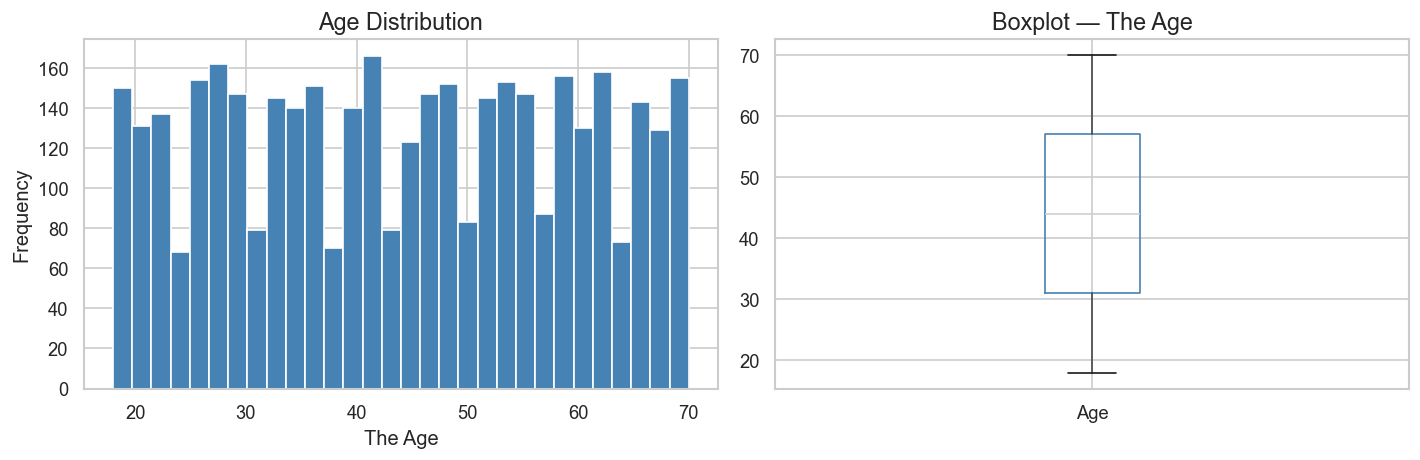

In [8]:
col = 'Age'

print(f'Range : {df[col].min()} – {df[col].max()}')
#print(df[col].describe())

# Checking for anomalies using IQR
Q1, Q3 = df[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
print(f'Outliers (IQR): {len(outliers)}\n')

# Graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Histogram
df[col].plot.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('The Age')
# Boxplot
df.boxplot(column=col, ax=axes[1], boxprops=dict(color='steelblue'))
axes[1].set_title('Boxplot — The Age')
plt.tight_layout()
plt.show()


#### 2.3 — `Gender` 

Unique Values : ['Male' 'Female']
Extra Distances: 0
Gender
Male      2652
Female    1248
Name: count, dtype: int64


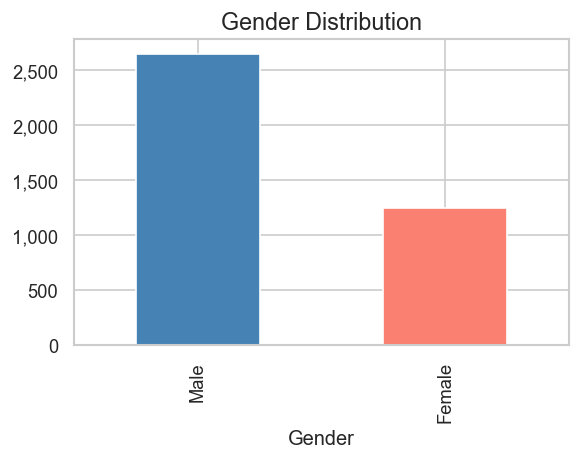

Percentage of Males : 68.0
Percentage of Female : 32.0


In [9]:
col = 'Gender'

print(f'Unique Values : {df[col].unique()}')
print(f'Extra Distances: {(df[col] != df[col].str.strip()).sum()}')
print(df[col].value_counts())

# Graphs
fig, ax = plt.subplots(figsize=(5, 4))
df[col].value_counts().plot.bar(ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
ax.set_title('Gender Distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# Note on Distribution
male_pctM = (df[col] == 'Male').mean() * 100
male_pctF = (df[col] == 'Female').mean() * 100
print(f'Percentage of Males : {male_pctM}')
print(f'Percentage of Female : {male_pctF}')

#### 2.4 — `Item Purchased` 

Unique Values : 25
Extra Distances : 0
Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64


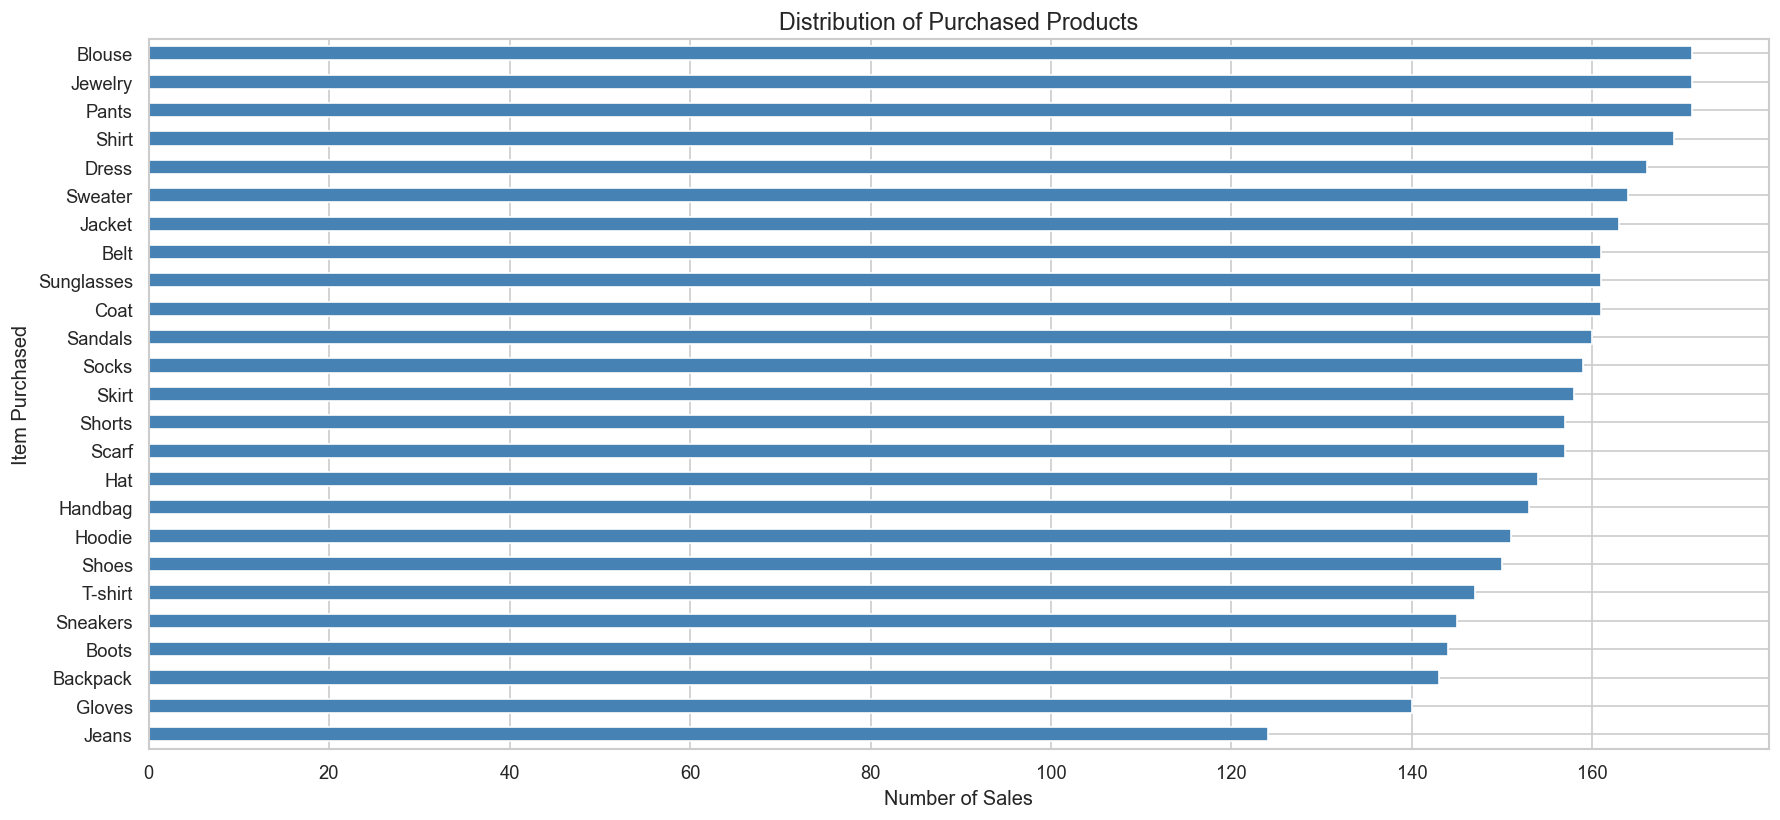

In [10]:
col = 'Item Purchased'

print(f'Unique Values : {df[col].nunique()}')
print(f'Extra Distances : {(df[col] != df[col].str.strip()).sum()}')
print(df[col].value_counts())

# Graphs
fig, ax = plt.subplots(figsize=(15, 7))
df[col].value_counts().sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Purchased Products')
ax.set_xlabel('Number of Sales')
plt.tight_layout()
plt.show()

#### 2.5 — `Category` 

Unique Values : ['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

=== Linking the category to the products ===
Accessories: ['Backpack', 'Belt', 'Gloves', 'Handbag', 'Hat', 'Jewelry', 'Scarf', 'Sunglasses']
Clothing: ['Blouse', 'Dress', 'Hoodie', 'Jeans', 'Pants', 'Shirt', 'Shorts', 'Skirt', 'Socks', 'Sweater', 'T-shirt']
Footwear: ['Boots', 'Sandals', 'Shoes', 'Sneakers']
Outerwear: ['Coat', 'Jacket']


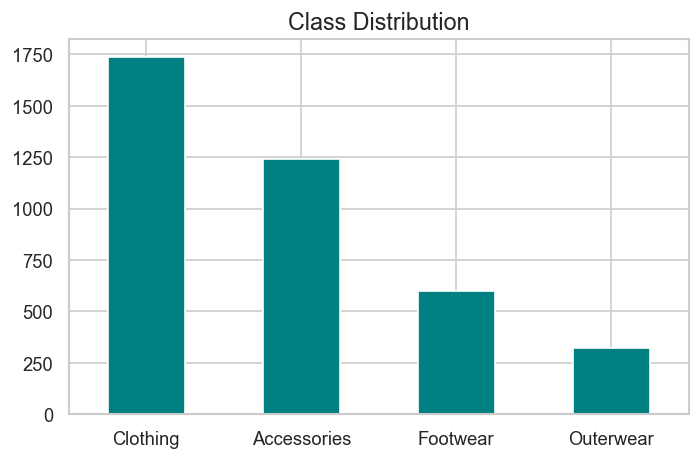

In [11]:
col = 'Category'

print(f'Unique Values : {df[col].unique()}\n')
print(df[col].value_counts())

# Check that the category matches the item purchased
print('\n=== Linking the category to the products ===')
mapping = df.groupby(col)['Item Purchased'].unique()
for cat, items in mapping.items():
    print(f'{cat}: {sorted(items)}')

# Graphs
fig, ax = plt.subplots(figsize=(6, 4))
df[col].value_counts().plot.bar(ax=ax, color='teal', edgecolor='white')
ax.set_title('Class Distribution')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### 2.6 — `Purchase Amount (USD)` 


Abnormal Values (IQR): 0



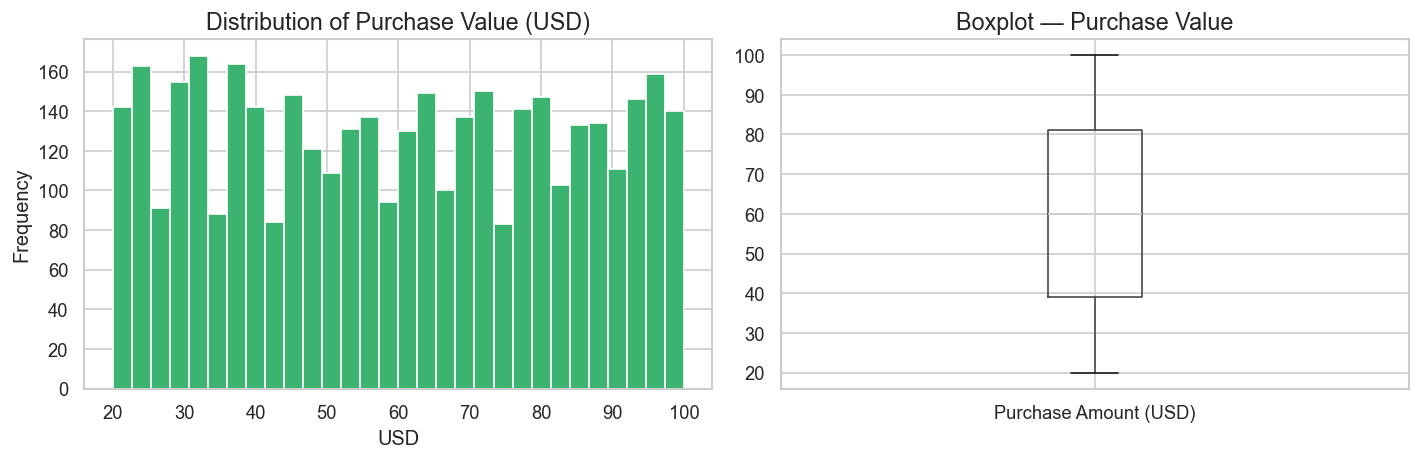

In [12]:
col = 'Purchase Amount (USD)'


Q1, Q3 = df[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
print(f'\nAbnormal Values (IQR): {len(outliers)}\n')

# Graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[col].plot.hist(bins=30, ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribution of Purchase Value (USD)')
axes[0].set_xlabel('USD')
df.boxplot(column=col, ax=axes[1])
axes[1].set_title('Boxplot — Purchase Value')
plt.tight_layout()
plt.show()



#### 2.7 — `Location` 

Unique Values : 50 (US State)
Extra Distances: 0

Top 10 best-selling states :
Location
Montana       96
California    95
Idaho         93
Illinois      92
Alabama       89
Minnesota     88
Nebraska      87
New York      87
Nevada        87
Maryland      86
Name: count, dtype: int64

The 10 lowest-selling states :
Location
Utah             71
New Hampshire    71
South Dakota     70
Iowa             69
Florida          68
New Jersey       67
Hawaii           65
Arizona          65
Kansas           63
Rhode Island     63
Name: count, dtype: int64


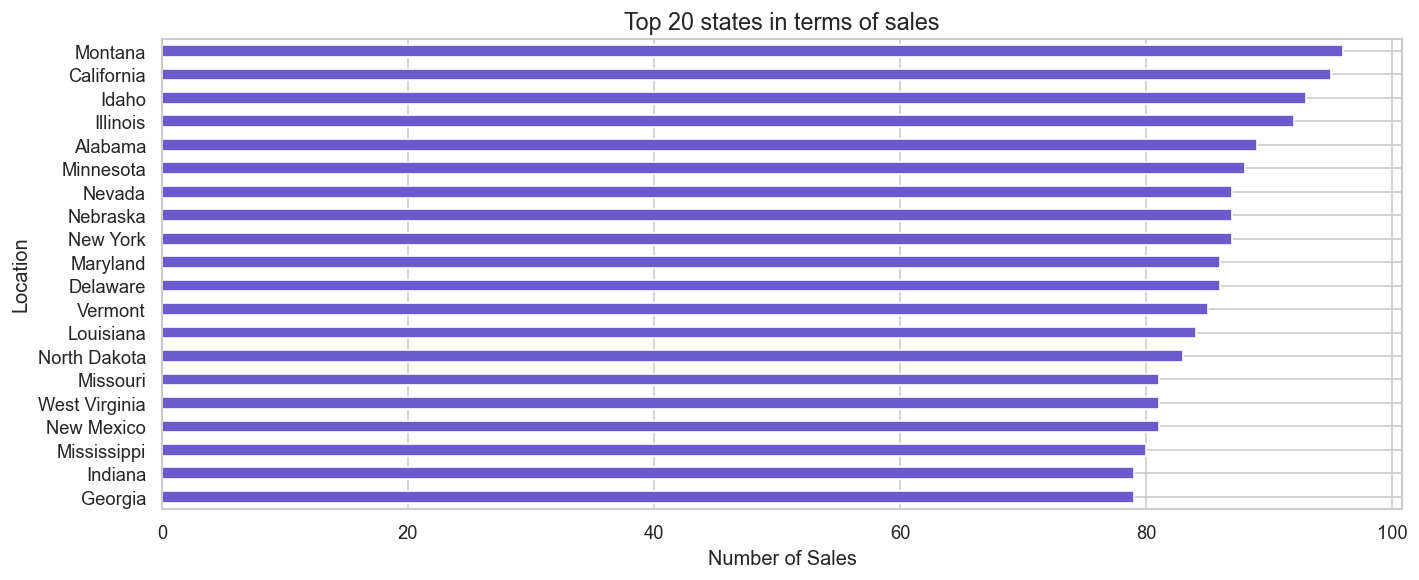

In [13]:
col = 'Location'

print(f'Unique Values : {df[col].nunique()} (US State)')
print(f'Extra Distances: {(df[col] != df[col].str.strip()).sum()}')

print('\nTop 10 best-selling states :')
print(df[col].value_counts().head(10))
print('\nThe 10 lowest-selling states :')
print(df[col].value_counts().tail(10))

# Graphs
fig, ax = plt.subplots(figsize=(12, 5))
df[col].value_counts().head(20).sort_values().plot.barh(ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Top 20 states in terms of sales')
ax.set_xlabel('Number of Sales')
plt.tight_layout()
plt.show()

#### 2.8 — `Size` 

Unique Values : ['L' 'S' 'M' 'XL']

Size
S      663
M     1755
L     1053
XL     429
Name: count, dtype: int64


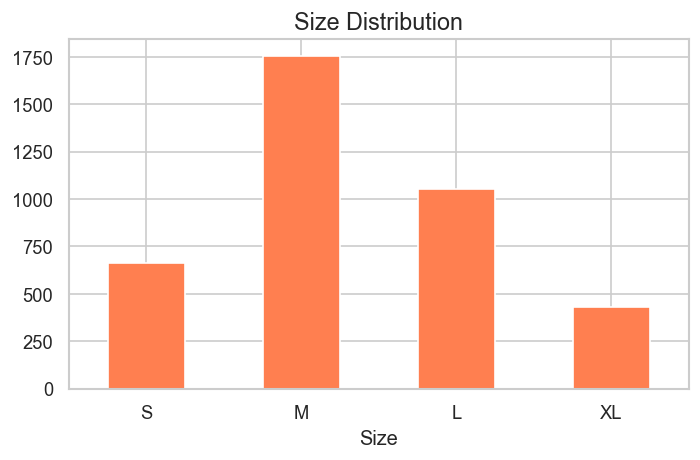

In [14]:
col = 'Size'

print(f'Unique Values : {df[col].unique()}\n')

# Logical Arrangement of Sizes
size_order = ['S', 'M', 'L', 'XL']
size_counts = df[col].value_counts().reindex(size_order)
print(size_counts)

# Graphs
fig, ax = plt.subplots(figsize=(6, 4))
size_counts.plot.bar(ax=ax, color='coral', edgecolor='white')
ax.set_title('Size Distribution')
ax.set_xlabel('Size')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 2.9 — `Color` 

Unique Values : 25
Extra Distances : 0

Color
Olive        177
Yellow       174
Silver       173
Teal         172
Green        169
Black        167
Cyan         166
Violet       166
Gray         159
Maroon       158
Orange       154
Charcoal     153
Pink         153
Magenta      152
Blue         152
Purple       151
Peach        149
Red          148
Beige        147
Indigo       147
Lavender     147
Turquoise    145
White        142
Brown        141
Gold         138
Name: count, dtype: int64


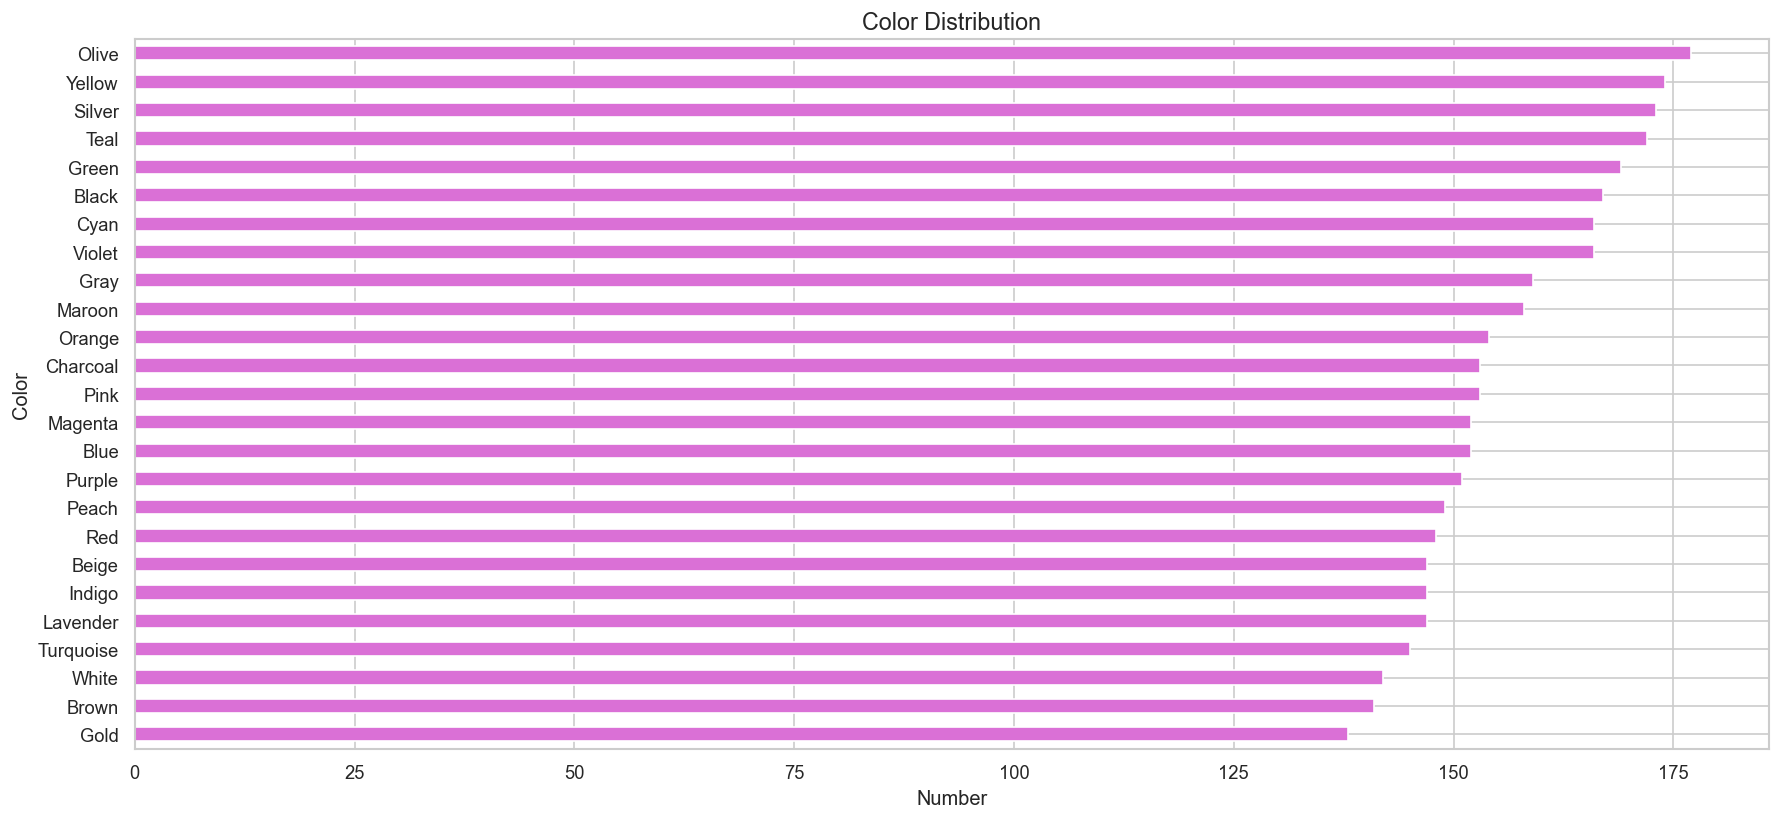

In [15]:
col = 'Color'

print(f'Unique Values : {df[col].nunique()}')
print(f'Extra Distances : {(df[col] != df[col].str.strip()).sum()}\n')
print(df[col].value_counts())

fig, ax = plt.subplots(figsize=(15, 7))
df[col].value_counts().sort_values().plot.barh(ax=ax, color='orchid', edgecolor='white')
ax.set_title('Color Distribution')
ax.set_xlabel('Number')
plt.tight_layout()
plt.show()

#### 2.10 — `Season` 

Unique Values : ['Winter' 'Spring' 'Summer' 'Fall']
Extra Distances : 0

Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64


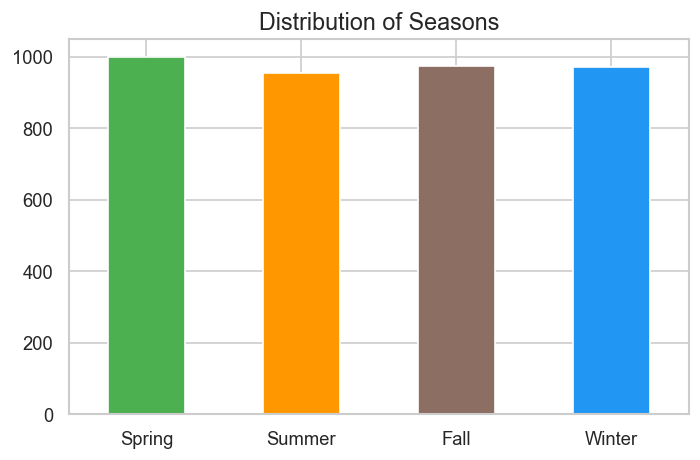

In [16]:
col = 'Season'

print(f'Unique Values : {df[col].unique()}')
print(f'Extra Distances : {df[col].isnull().sum()}\n')
print(df[col].value_counts())


season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_colors = ['#4CAF50', '#FF9800', '#8D6E63', '#2196F3']

# Graphs
fig, ax = plt.subplots(figsize=(6, 4))
df[col].value_counts().reindex(season_order).plot.bar(
    ax=ax, color=season_colors, edgecolor='white')
ax.set_title('Distribution of Seasons')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 2.11 — `Review Rating` 

Missing values : 37 (0.95%)
Range : 2.5 – 5.0

=== Missing Values for Each Category ===
Category
Accessories    11
Clothing       19
Footwear        5
Outerwear       2
Name: Missing Values, dtype: int64



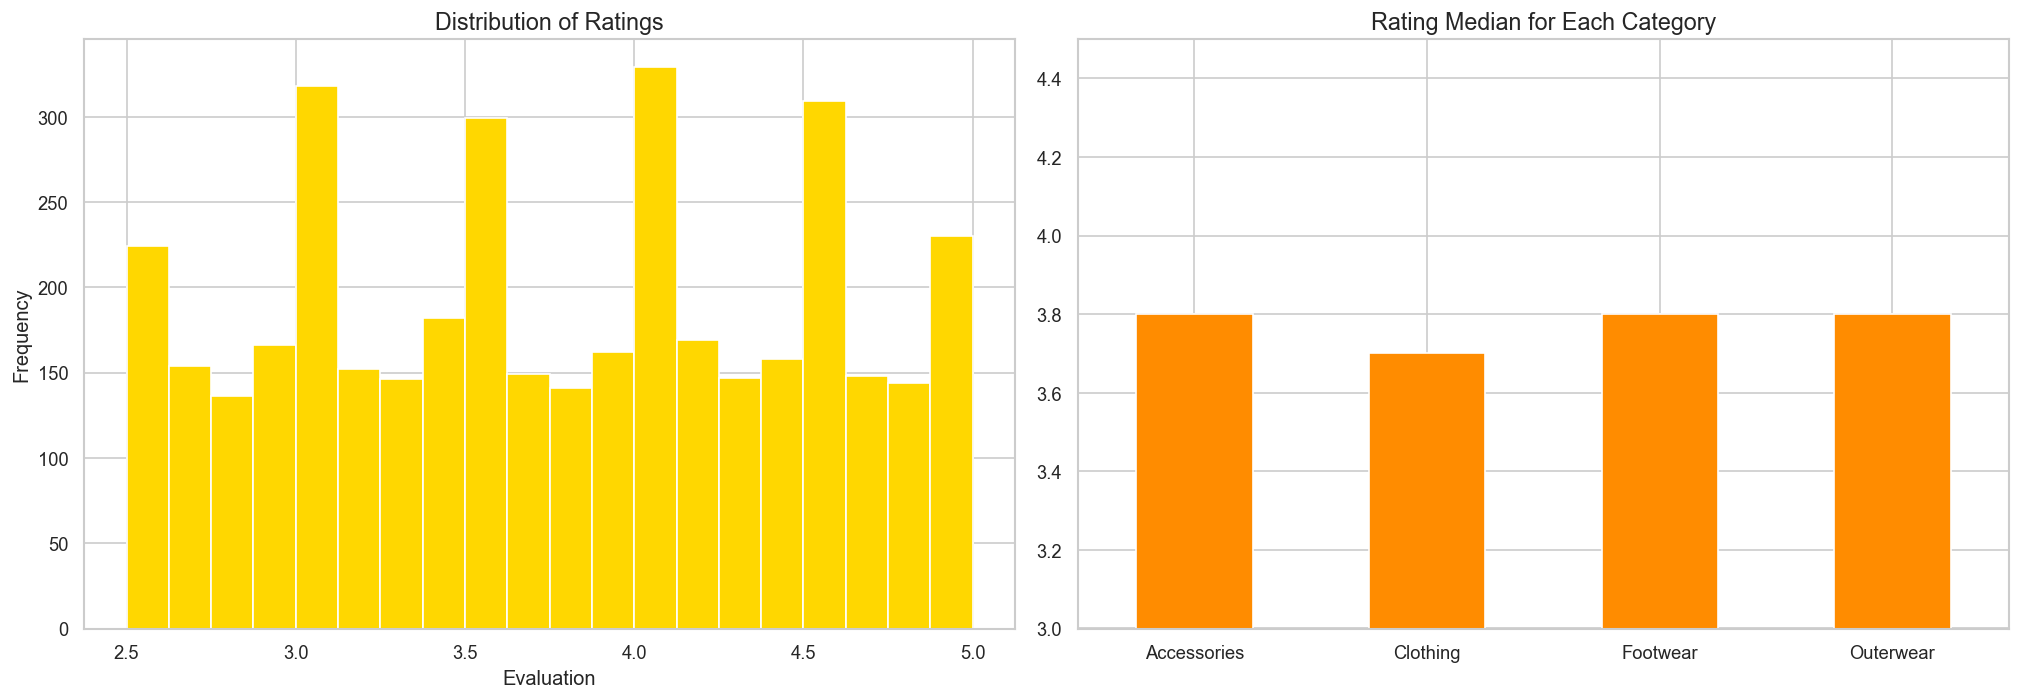

In [17]:
col = 'Review Rating'

print(f'Missing values : {df[col].isnull().sum()} ({df[col].isnull().mean()*100:.2f}%)')
print(f'Range : {df[col].min()} – {df[col].max()}\n')

# Distributing missing values across categories
print('=== Missing Values for Each Category ===')
print(df.groupby('Category')[col].apply(lambda x: x.isnull().sum()).rename('Missing Values'))
print()

# Graphs
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

df[col].plot.hist(bins=20, ax=axes[0], color='gold', edgecolor='white')
axes[0].set_title('Distribution of Ratings')
axes[0].set_xlabel('Evaluation')


# Rating median for each category
df.groupby('Category')[col].median().plot.bar(ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Rating Median for Each Category')
axes[1].set_xlabel('')
axes[1].set_ylim(3, 4.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 2.12 — `Subscription Status` 

Unique Values : ['Yes' 'No']

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

Subscriber Percentage : 27.0%



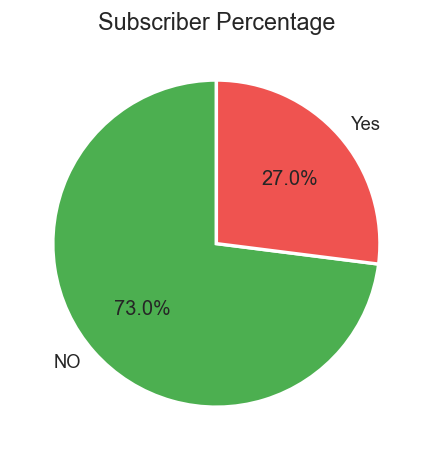

In [18]:
col = 'Subscription Status'

print(f'Unique Values : {df[col].unique()}\n')
print(df[col].value_counts())
print(f'\nSubscriber Percentage : {(df[col]=="Yes").mean()*100:.1f}%\n')

# Graphs
fig, ax = plt.subplots(figsize=(5, 4))
df[col].value_counts().plot.pie(
    ax=ax, colors=['#4CAF50', '#ef5350'],
    autopct='%1.1f%%', startangle=90,
    labels=['NO', 'Yes'], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Subscriber Percentage')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

#### 2.13 — `Shipping Type` 

Unique Values : 6
Extra Distances : 0

Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64


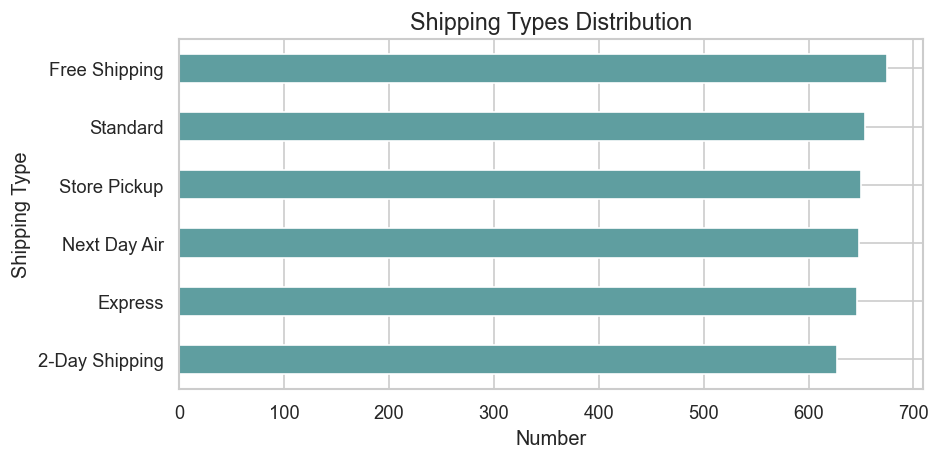

In [19]:
col = 'Shipping Type'

print(f'Unique Values : {df[col].nunique()}')
print(f'Extra Distances : {(df[col] != df[col].str.strip()).sum()}\n')
print(df[col].value_counts())

# Graphs
fig, ax = plt.subplots(figsize=(8, 4))
df[col].value_counts().sort_values().plot.barh(
    ax=ax, color='cadetblue', edgecolor='white')
ax.set_title('Shipping Types Distribution')
ax.set_xlabel('Number')
plt.tight_layout()
plt.show()

#### 2.14 — `Discount Applied` & `Promo Code Used` 

In [20]:
for col in ['Discount Applied', 'Promo Code Used']:
    print(f'=== {col} ===')
    print(f'Unique Values : {df[col].unique()}')
    print(df[col].value_counts())
    print()

# Check if the two columns are identical or not
identical = (df['Discount Applied'] == df['Promo Code Used']).all()
print(f'Are the two columns identical in each row? {identical}')

cross_tab = pd.crosstab(df['Discount Applied'], df['Promo Code Used'])
print('\nCross-tabulation:\n')
print(cross_tab)



=== Discount Applied ===
Unique Values : ['Yes' 'No']
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

=== Promo Code Used ===
Unique Values : ['Yes' 'No']
Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64

Are the two columns identical in each row? True

Cross-tabulation:

Promo Code Used     No   Yes
Discount Applied            
No                2223     0
Yes                  0  1677


#### 2.15 — `Previous Purchases` 


Abnormal Values (IQR): 0



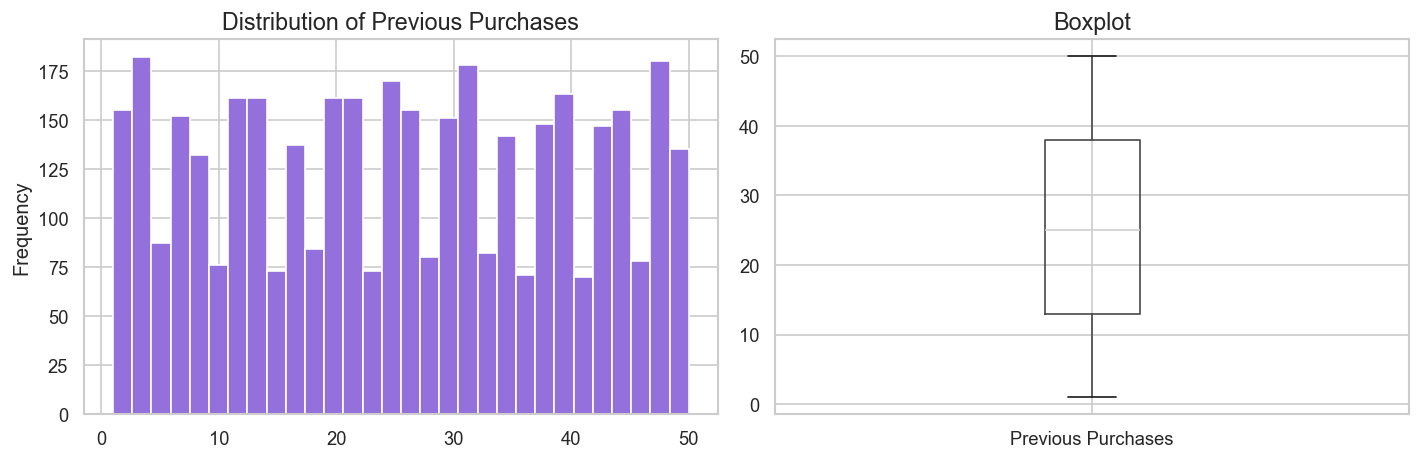

In [21]:
col = 'Previous Purchases'


Q1, Q3 = df[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
print(f'\nAbnormal Values (IQR): {len(outliers)}\n')

# Graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[col].plot.hist(bins=30, ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Distribution of Previous Purchases')
df.boxplot(column=col, ax=axes[1])
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.show()

#### 2.16 — `Payment Method` 

Unique Values : 6

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64



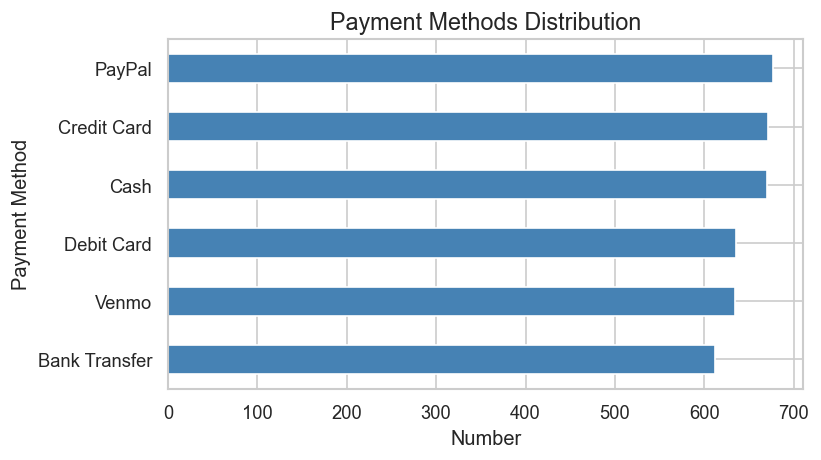

In [22]:
col = 'Payment Method'

print(f'Unique Values : {df[col].nunique()}\n')
print(df[col].value_counts())
print()

# Graphs
fig, ax = plt.subplots(figsize=(7, 4))
df[col].value_counts().sort_values().plot.barh(
    ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Payment Methods Distribution')
ax.set_xlabel('Number')
plt.tight_layout()
plt.show()

#### 2.17 — `Frequency of Purchases` 

Unique Values : ['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'Monthly'
 'Every 3 Months']

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

Fortnightly: 542 Row
Bi-Weekly  : 547 Row



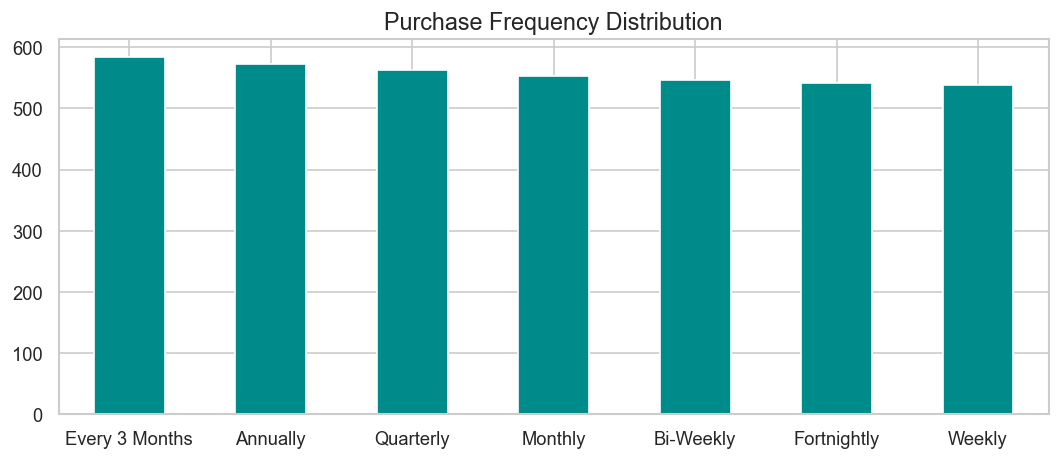

In [23]:
col = 'Frequency of Purchases'

print(f'Unique Values : {df[col].unique()}\n')
print(df[col].value_counts())

# Important note: Fortnightly and Bi-Weekly mean the same thing (14 days)
fortnightly = df[df[col] == 'Fortnightly'].shape[0]
biweekly = df[df[col] == 'Bi-Weekly'].shape[0]
print(f'\nFortnightly: {fortnightly} Row')
print(f'Bi-Weekly  : {biweekly} Row\n')

# Graphs
fig, ax = plt.subplots(figsize=(9, 4))
df[col].value_counts().plot.bar(ax=ax, color='darkcyan', edgecolor='white')
ax.set_title('Purchase Frequency Distribution')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3 — EDA Summary

In [24]:
summary = {
    'Customer ID'             : ('✅ Clean', 'Sequential unique identifier'),
    'Age'                     : ('✅ Clean', 'No missing values or outliers'),
    'Gender'                  : ('⚠️ Attention', '68% male — imbalanced distribution'),
    'Item Purchased'          : ('✅ Clean', '25 products, balanced distribution'),
    'Category'                : ('✅ Clean', '4 categories, correctly linked with products'),
    'Purchase Amount (USD)'   : ('✅ Clean', 'Range $20–$100, no outliers'),
    'Location'                : ('✅ Clean', '50 U.S. states'),
    'Size'                    : ('✅ Clean', 'Only S/M/L/XL values'),
    'Color'                   : ('✅ Clean', '25 colors, balanced distribution'),
    'Season'                  : ('✅ Clean', '4 balanced seasons'),
    'Review Rating'           : ('🔧 Needs processing', '37 missing values (0.95%)'),
    'Subscription Status'     : ('✅ Clean', 'Only Yes/No values'),
    'Shipping Type'           : ('✅ Clean', '6 balanced shipping types'),
    'Discount Applied'        : ('✅ Clean', 'Only Yes/No values'),
    'Promo Code Used'         : ('🗑️ Will be removed', 'Exactly identical to Discount Applied'),
    'Previous Purchases'      : ('✅ Clean', 'Range 1–50, no outliers'),
    'Payment Method'          : ('✅ Clean', '6 balanced payment methods'),
    'Frequency of Purchases'  : ('⚠️ Needs standardization', 'Fortnightly = Bi-Weekly'),
}

summary_df = pd.DataFrame.from_dict(
    summary, orient='index', columns=['Status', 'Note']
)

print('=== Column Status Summary ===')
print(summary_df.to_string())

=== Column Status Summary ===
                                          Status                                          Note
Customer ID                              ✅ Clean                  Sequential unique identifier
Age                                      ✅ Clean                 No missing values or outliers
Gender                              ⚠️ Attention            68% male — imbalanced distribution
Item Purchased                           ✅ Clean            25 products, balanced distribution
Category                                 ✅ Clean  4 categories, correctly linked with products
Purchase Amount (USD)                    ✅ Clean                   Range $20–$100, no outliers
Location                                 ✅ Clean                                50 U.S. states
Size                                     ✅ Clean                          Only S/M/L/XL values
Color                                    ✅ Clean              25 colors, balanced distribution
Season              

## 4 — Data Cleaning

#### 4.1 — Removing Duplicate Rows (Precautionary)

In [25]:
before = len(df)
df = df.drop_duplicates()  # Save the result in df
after = len(df)
print(f'— Before : {before:,} \n— After : {after:,} \n— Deleted : {before - after}')

— Before : 3,900 
— After : 3,900 
— Deleted : 0


#### 4.2 — Fill in the missing values in `Review Rating` using the category argument

In [26]:
# Why the median for each category? Because each category (Clothing, Footwear, etc.) may have a different rating distribution.
#The median is more resistant to outliers than the mean.

before_null = df['Review Rating'].isnull().sum()

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(
    lambda x: x.fillna(x.median())  
)

after_null = df['Review Rating'].isnull().sum()
print(f'Values Lost Before: {before_null} — After: {after_null}')
print(f'Data Type After Processing: {df["Review Rating"].dtype}')  # يجب أن يكون float64

Values Lost Before: 37 — After: 0
Data Type After Processing: float64


#### 4.3 — Delete `Promo Code Used` 

In [27]:
df = df.drop(columns=['Promo Code Used'])
print('A column was deleted (Promo Code Used)')
print(f'The Columns Now: {df.shape[1]}')

A column was deleted (Promo Code Used)
The Columns Now: 17


#### 4.4 — Unification `Frequency of Purchases` (Fortnightly → Bi-Weekly)

In [28]:
# Fortnightly and Bi-Weekly both mean "every two weeks" — let's unify them
df['Frequency of Purchases'] = df['Frequency of Purchases'].replace(
    'Fortnightly', 'Bi-Weekly'
)
print('After Unification:')
print(df['Frequency of Purchases'].value_counts())

After Unification:
Frequency of Purchases
Bi-Weekly         1089
Every 3 Months     584
Annually           572
Quarterly          563
Monthly            553
Weekly             539
Name: count, dtype: int64


#### 4.5 — Standardizing column names (SQL-friendly)

In [29]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace(r'[^a-z0-9_]', '', regex=True) # Remove Special Symbols
)

# Rename the Column
df = df.rename(columns={'purchase_amount_usd': 'purchase_amount'})

print(df.columns.tolist())

['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


#### 4.6 — Final Verification of Data Integrity

In [30]:
print('=== Final Inspection ===')
print(f'Dimensions          : {df.shape}')
print(f'Missing Values      : {df.isnull().sum().sum()}')
print(f'Repeated Rows       : {df.duplicated().sum()}')
print()
print('Data Types:')
print(df.dtypes)
print()
df.head()

=== Final Inspection ===
Dimensions          : (3900, 17)
Missing Values      : 0
Repeated Rows       : 0

Data Types:
customer_id                 int64
age                         int64
gender                     object
item_purchased             object
category                   object
purchase_amount             int64
location                   object
size                       object
color                      object
season                     object
review_rating             float64
subscription_status        object
shipping_type              object
discount_applied           object
previous_purchases          int64
payment_method             object
frequency_of_purchases     object
dtype: object



,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Bi-Weekly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Bi-Weekly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually


## 5 —  Feature Engineering

#### 5.1 — `age_group` 

In [31]:
# 'Young Adult (18-30)', 'Adult (31-45)', 'Middle-Aged (46-60)', 'Senior (61-70)'
bins   = [18, 30, 45, 60, 70]
labels = ['Young Adult', 'Adult', 'Middle-Aged', 'Senior']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
).astype(str) # Convert directly to string to avoid categorical problems in SQL

print(df['age_group'].value_counts())

# Check: No NaN values after partitioning
print(f'\nMissing values in (age_group) : {df["age_group"].isnull().sum()}')

age_group
Middle-Aged    1135
Adult          1093
Young Adult     949
Senior          723
Name: count, dtype: int64

Missing values in (age_group) : 0


#### 5.2 — `purchases_frequency_days` 

In [32]:
frequency_mapping = {
    'Weekly'        :  7,
    'Bi-Weekly'     : 14,   # Includes Fortnightly after unification
    'Monthly'       : 30,
    'Quarterly'     : 90,
    'Every 3 Months': 90,   # Same Quarterly
    'Annually'      : 365,
}

df['purchases_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

# Check for no NaN values (i.e., a value not present in the mapping)
unmapped = df['purchases_frequency_days'].isnull().sum()
print(f'Unspecified Values : {unmapped}')
print()

# Show Result
df[['frequency_of_purchases', 'purchases_frequency_days']].drop_duplicates().sort_values('purchases_frequency_days')

Unspecified Values : 0



,frequency_of_purchases,purchases_frequency_days
2,Weekly,7
0,Bi-Weekly,14
15,Monthly,30
6,Quarterly,90
20,Every 3 Months,90
4,Annually,365


#### 5.3 — `Final State of Data`

In [33]:
print(f'Final Dimensions : {df.shape}')
print(f'Missing Values   : {df.isnull().sum().sum()}')
print()
print('Final Data Types:')
print(df.dtypes)
print()
df.head()

Final Dimensions : (3900, 19)
Missing Values   : 0

Final Data Types:
customer_id                   int64
age                           int64
gender                       object
item_purchased               object
category                     object
purchase_amount               int64
location                     object
size                         object
color                        object
season                       object
review_rating               float64
subscription_status          object
shipping_type                object
discount_applied             object
previous_purchases            int64
payment_method               object
frequency_of_purchases       object
age_group                    object
purchases_frequency_days      int64
dtype: object



,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchases_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Bi-Weekly,Middle-Aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Bi-Weekly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-Aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Adult,365


---
## 6 — Export to SQL Server

In [34]:
# Installing the Necessary Libraries
%pip install pyodbc sqlalchemy --quiet

Note: you may need to restart the kernel to use updated packages.


In [35]:
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [36]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

server   = r'localhost\SQLEXPRESS'
database = 'customer_behavior'
driver   = quote_plus('ODBC Driver 17 for SQL Server')

engine = create_engine(
    f'mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes',
    fast_executemany=True  
)

print('Connection Established Successfully')

Connection Established Successfully


In [37]:
# Ensure that the data types are compatible with SQL before exporting
print('Specimen Inspection Before Export:')
print(df.dtypes)
print(f'\nMissing Values: {df.isnull().sum().sum()}')

Specimen Inspection Before Export:
customer_id                   int64
age                           int64
gender                       object
item_purchased               object
category                     object
purchase_amount               int64
location                     object
size                         object
color                        object
season                       object
review_rating               float64
subscription_status          object
shipping_type                object
discount_applied             object
previous_purchases            int64
payment_method               object
frequency_of_purchases       object
age_group                    object
purchases_frequency_days      int64
dtype: object

Missing Values: 0


In [38]:
# Export to SQL
rows = df.to_sql(
    'customer',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=500    
)

print(f'Exported {rows:,} Successfully added to the customer table✅')

Exported -8 Successfully added to the customer table✅


In [39]:
# Verification by Reading the First 5 Rows of SQL
import pandas as pd
result = pd.read_sql('SELECT TOP 5 * FROM customer', engine)
result

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchases_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Bi-Weekly,Middle-Aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Bi-Weekly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-Aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Adult,365


---
## Project Summary

| Step | Result |
|--------|--------|
| Original Data | 3,900 rows × 18 columns |
| Duplicate Rows Removed | 0 |
| Missing Values Processed | 37 in `Review Rating` → filled with category median |
| Columns Removed | `Promo Code Used` (duplicate) |
| Standardization | `Fortnightly` → `Bi-Weekly` |
| Features Added | `age_group`, `purchases_frequency_days`, `loyalty_tier` |
| Final Dataset | 3,900 rows × 20 columns |
| Export | Table `customer` in the `customer_behavior` database |